# Variability of DA White Dwarfs in Rubin EDP2

In this tutorial, we will:
- collect known DA white dwarf positions from recent literature, via SIMBAD bibcode queries and a VizieR table
- load Rubin DP2 forced-source photometry with LSDB, including new columns with corrected flux-error estimates
- cross-match the two catalogs and plot the resulting light curves, comparing original and corrected flux errors

## Introduction

### Prerequisites

In order to access Rubin data, you must be a [Rubin data rights holder](https://rubinobservatory.org/for-scientists/data-products/data-policy), and run this notebook from a platform with access to the DP2 HATS catalogs, such as the Rubin Science Platform (RSP).

In [1]:
import os

import astropy.table
import lsdb
import matplotlib.pyplot as plt
import numpy as np
from astroquery.simbad import Simbad
from astroquery.vizier import Vizier
from dask.distributed import Client

plt.rcParams.update(
    {
        "axes.titlesize": 16,
        "axes.labelsize": 15,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "legend.fontsize": 13,
        "figure.titlesize": 18,
    }
)

In [2]:
import logging

logging.getLogger().setLevel(logging.WARNING)
logging.getLogger("distributed").setLevel(logging.WARNING)

In [3]:
lsdb.show_versions()


--------      SYSTEM INFO      --------
python        : 3.13.13
python-bits   : 64
OS            : Linux
OS-release    : 4.18.0-372.32.1.el8_6.x86_64
Version       : #1 SMP Fri Oct 7 12:35:10 EDT 2022
machine       : x86_64
processor     : x86_64
byteorder     : little
LC_ALL        : 
LANG          : en_US.UTF-8
--------   INSTALLED VERSIONS   --------
lsdb          : 0.10.5.dev1+g36a32399e
hats          : 0.10.5.dev7+gd0f3656cb
nested-pandas : 0.6.10
pandas        : 2.3.3
numpy         : 2.3.5
dask          : 2026.3.0
pyarrow       : 23.0.0
fsspec        : 2026.3.0


## 1. Collect DA white dwarf positions from multiple papers

We query [SIMBAD](https://simbad.cds.unistra.fr/simbad/) for the objects cited in three recent DA white dwarf papers, identified by their bibcodes, and add one more table of positions from [VizieR](https://vizier.cds.unistra.fr).

In [4]:
simbad_bibcodes = [
    "2025A&A...701A.269G",
    "2025MNRAS.540..385B",
    "2025AJ....169...40B",
]

vizier_catalogs = [
    "J/A+A/699/A212/tableb2",  # https://ui.adsabs.harvard.edu/abs/2025A%26A...699A.212J
]

simbad = Simbad()
vizier = Vizier(columns=["_RAJ2000", "_DEJ2000"])

Query each paper's objects from SIMBAD and the VizieR table, keeping only right ascension and declination, and stack the results into a single astropy table.

In [5]:
tables = []

for bibcode in simbad_bibcodes:
    table = simbad.query_bibobj(bibcode)[["ra", "dec"]]
    tables.append(table)

for viz_cat in vizier_catalogs:
    table = vizier.get_catalogs(viz_cat)[0][["_RAJ2000", "_DEJ2000"]]
    table.rename_columns(["_RAJ2000", "_DEJ2000"], ["ra", "dec"])
    tables.append(table)

table = astropy.table.vstack(tables, metadata_conflicts="silent")
table

ra,dec
deg,deg
float64,float64
24.0567308228,-11.3423980207
349.9933320184,-5.1656030952
102.2336908394,-25.3963773716
90.0870523566,-10.2345829685
67.3593234723,-4.8126710103
77.5118826901,-0.6321245159
165.3010036032,-13.2450631543
154.9681774742,-14.1261809958


### 1.1 Convert to an LSDB catalog

We wrap the combined table with `lsdb.from_astropy` so it can be used as one side of the cross-match below.

In [6]:
da_cat = lsdb.from_astropy(table)
da_cat

,ra,dec
npartitions=12,,
"Order: 0, Pixel: 0",double[pyarrow],double[pyarrow]
...,...,...
"Order: 0, Pixel: 10",...,...
"Order: 0, Pixel: 11",...,...


## 2. Load the Rubin DP2 forced-source catalog

We open the DP2 object collection catalog, requesting all default columns plus two new nested forced-source subcolumns: `psfFluxErr_corrected` and `psfDiffFluxErr_corrected`.

Four new subcolumns are added to the nested forced-source tables (`objectForcedSource` and `diaObjectForcedSource`): `psfFluxErr_corrected`, `psfDiffFluxErr_corrected`, `psfFluxErr_corrected_flag`, and `psfDiffFluxErr_corrected_flag`. They come from a model trained to correct flux errors so that, for non-variable objects, the light curve's reduced χ² is close to unity — these corrected values may be useful for light-curve fitting. The flag columns are `True` when the ratio between the original and corrected errors falls outside the [0.1, 50] interval. See Malanchev et al., in prep., for details; source code is available on [GitHub](http://github.com/lincc-frameworks/uncle-val).

We also filter to objects with PSF magnitude brighter than 22 in every band, to keep the cross-match in this tutorial small and fast.

In [7]:
dp2_obj = lsdb.open_catalog(
    "/sdf/data/rubin/shared/lsdb_commissioning/hats/dp2_rc/object_collection",
    columns=[
        ...,  # all default columns
        "objectForcedSource.psfFluxErr_corrected",
        "objectForcedSource.psfDiffFluxErr_corrected",
    ],
    # Filter data on the read time: keep objects which are brighter 22 mag
    # in any band, since we know that these DA dwarfs are pretty bright.
    filters=[[(f"{band}_psfMag", "<", 22) for band in "ugrizy"]],
)
dp2_obj

,coord_dec,coord_decErr,coord_ra,coord_raErr,g_psfFlux,g_psfFluxErr,g_psfMag,g_psfMagErr,i_psfFlux,i_psfFluxErr,i_psfMag,i_psfMagErr,objectId,patch,r_psfFlux,r_psfFluxErr,r_psfMag,r_psfMagErr,refBand,shape_flag,shape_xx,shape_xy,shape_yy,tract,u_psfFlux,u_psfFluxErr,u_psfMag,u_psfMagErr,y_psfFlux,y_psfFluxErr,y_psfMag,y_psfMagErr,z_psfFlux,z_psfFluxErr,z_psfMag,z_psfMagErr,objectForcedSource
npartitions=8840,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
"Order: 8, Pixel: 10240",double[pyarrow],float[pyarrow],double[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],int64[pyarrow],int64[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],string[pyarrow],bool[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],int64[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],"nested<band: [string], coord_dec: [double], co..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 5, Pixel: 12283",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 5, Pixel: 12284",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


## 3. Cross-match with Rubin DP2

We cross-match the literature white dwarf positions against the DP2 objects within 5 arcsec. As with all LSDB operations, this only plans the cross-match — no data has been loaded yet (see [Lazy evaluation](./lazy_operations.html)).

In [8]:
xmatch = dp2_obj.crossmatch(da_cat, radius_arcsec=5, suffix_method="overlapping_columns")
xmatch

,coord_dec,coord_decErr,coord_ra,coord_raErr,g_psfFlux,g_psfFluxErr,g_psfMag,g_psfMagErr,i_psfFlux,i_psfFluxErr,i_psfMag,i_psfMagErr,objectId,patch,r_psfFlux,r_psfFluxErr,r_psfMag,r_psfMagErr,refBand,shape_flag,shape_xx,shape_xy,shape_yy,tract,u_psfFlux,u_psfFluxErr,u_psfMag,u_psfMagErr,y_psfFlux,y_psfFluxErr,y_psfMag,y_psfMagErr,z_psfFlux,z_psfFluxErr,z_psfMag,z_psfMagErr,objectForcedSource,ra,dec,_dist_arcsec
npartitions=16,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
"Order: 5, Pixel: 4505",double[pyarrow],float[pyarrow],double[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],int64[pyarrow],int64[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],string[pyarrow],bool[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],int64[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],"nested<band: [string], coord_dec: [double], co...",double[pyarrow],double[pyarrow],double[pyarrow]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 7, Pixel: 195352",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 6, Pixel: 49101",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


## 4. Run the pipeline

Now we create a local Dask cluster and run the cross-match. See the [Dask Client tutorial](./dask_client.html) for tips on configuring Dask for LSDB.

In [9]:
with Client(
    n_workers=2,
    threads_per_worker=1,
    memory_limit="8GB",
    local_directory=f"/deleted-sundays/{os.environ.get('USER', 'dask_scratch')}",
) as client:
    print(f"Dask dashboard: {client.dashboard_link}")
    display(client)
    df = xmatch.compute()

df

Dask dashboard: http://127.0.0.1:8787/status


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 2
Total threads: 2,Total memory: 14.90 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:23907,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:21299,Total threads: 1
Dashboard: http://127.0.0.1:26633/status,Memory: 7.45 GiB
Nanny: tcp://127.0.0.1:9431,


Computing Catalog:   0%|          | 0/16 [00:00<?, ?it/s]

coord_dec  coord_decErr    coord_ra  coord_raErr  \
_healpix_29                                                             
1918058228703156167   2.339937           0.0  151.161863          0.0   
1918186924080762372   2.642915           0.0  150.653521          0.0   
2164146647781502823 -15.598661      0.000001  244.479173     0.000001   
3377248907570746225 -27.208014      0.000004  297.333079     0.000004   
3377248907581042017 -27.208113      0.000005  297.332446     0.000007   
3377248907851940554 -27.206832      0.000001  297.333607     0.000001   
3436679681683128908 -17.212113      0.000024  304.375029     0.000043   
3436679681692705429 -17.212204           0.0  304.374529          0.0   

                         g_psfFlux  g_psfFluxErr   g_psfMag  g_psfMagErr  \
_healpix_29                                                                
1918058228703156167   61795.765625     27.427217  19.422604     0.000482   
1918186924080762372  188631.109375     43.119041  18.210966     0.000248   
2164146647781502823  111321.867188    329.714508  18.783548     0.003216   
3377248907570746225    213423.0625    413.866516  18.076897     0.002105   
3377248907581042017  175127.578125    539.417358  18.291615     0.003344   
3377248907851940554   33922.066406    181.681366  20.073793     0.005815   
3436679681683128908     103467.875    361.999237  18.862986     0.003799   
3436679681692705429    182583.5625    412.527496  18.246346     0.002453   

                         i_psfFlux  i_psfFluxErr  ...   y_psfMag  y_psfMagErr  \
_healpix_29                                       ...                           
1918058228703156167   79364.007812     36.498375  ...  19.220362      0.00423   
1918186924080762372  135714.796875     41.864441  ...  18.918549     0.003569   
2164146647781502823      235259.25    602.124512  ...  18.772018     0.005579   
3377248907570746225   137101.59375    468.876129  ...   19.56534     0.016301   
3377248907581042017  173459.453125    425.247406  ...  18.947632     0.009645   
3377248907851940554  135133.453125    190.545258  ...  18.179893     0.004227   
3436679681683128908   42099.976562    176.454575  ...  21.600788     0.067697   
3436679681692705429      3123214.0    723.848938  ...   15.44169     0.000488   

                         z_psfFlux  z_psfFluxErr   z_psfMag  z_psfMagErr  \
_healpix_29                                                                
1918058228703156167   77672.953125     71.986633  19.174326     0.001006   
1918186924080762372  113173.359375     78.492111   18.76564     0.000753   
2164146647781502823   91457.890625    358.204437  18.996946     0.004252   
3377248907570746225   15299.652344    547.012817  20.938295     0.038835   
3377248907581042017   77914.796875    515.328979   19.17095     0.007181   
3377248907851940554    163486.0625    374.220642  18.366299     0.002485   
3436679681683128908   28981.425781    426.063629  20.244701     0.015963   
3436679681692705429     2765065.25   1147.374634  15.295736      0.00045   

                                                    objectForcedSource  \
_healpix_29                                                              
1918058228703156167  [{band: 'i', coord_dec: 2.339937, coord_ra: 15...   
1918186924080762372  [{band: 'i', coord_dec: 2.642915, coord_ra: 15...   
2164146647781502823  [{band: 'z', coord_dec: -15.598661, coord_ra: ...   
3377248907570746225  [{band: 'z', coord_dec: -27.208014, coord_ra: ...   
3377248907581042017  [{band: 'z', coord_dec: -27.208113, coord_ra: ...   
3377248907851940554  [{band: 'z', coord_dec: -27.206832, coord_ra: ...   
3436679681683128908  [{band: 'i', coord_dec: -17.212113, coord_ra: ...   
3436679681692705429  [{band: 'i', coord_dec: -17.212204, coord_ra: ...   

                             ra        dec _dist_arcsec  
_healpix_29                                              
1918058228703156167  151.161887   2.339897     0.167428  
1918186924080762372  150.653515   2.642941

## 5. Plot the light curves

For each matched white dwarf, we plot the per-band `objectForcedSource` light curves in both science flux and difference flux, comparing error bars from the original `*Err` columns against the corrected `*Err_corrected` columns, and report the reduced χ² for each.

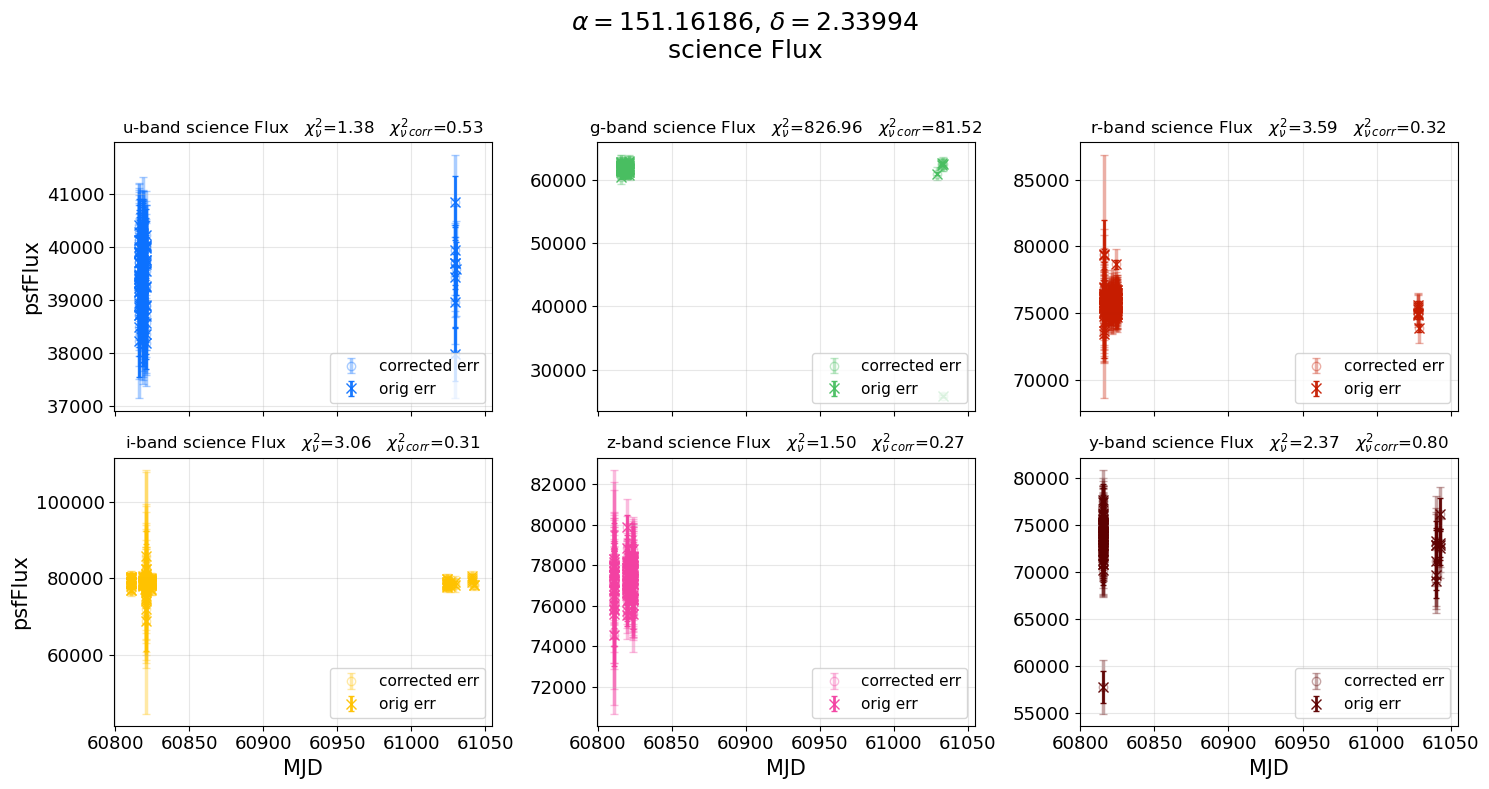

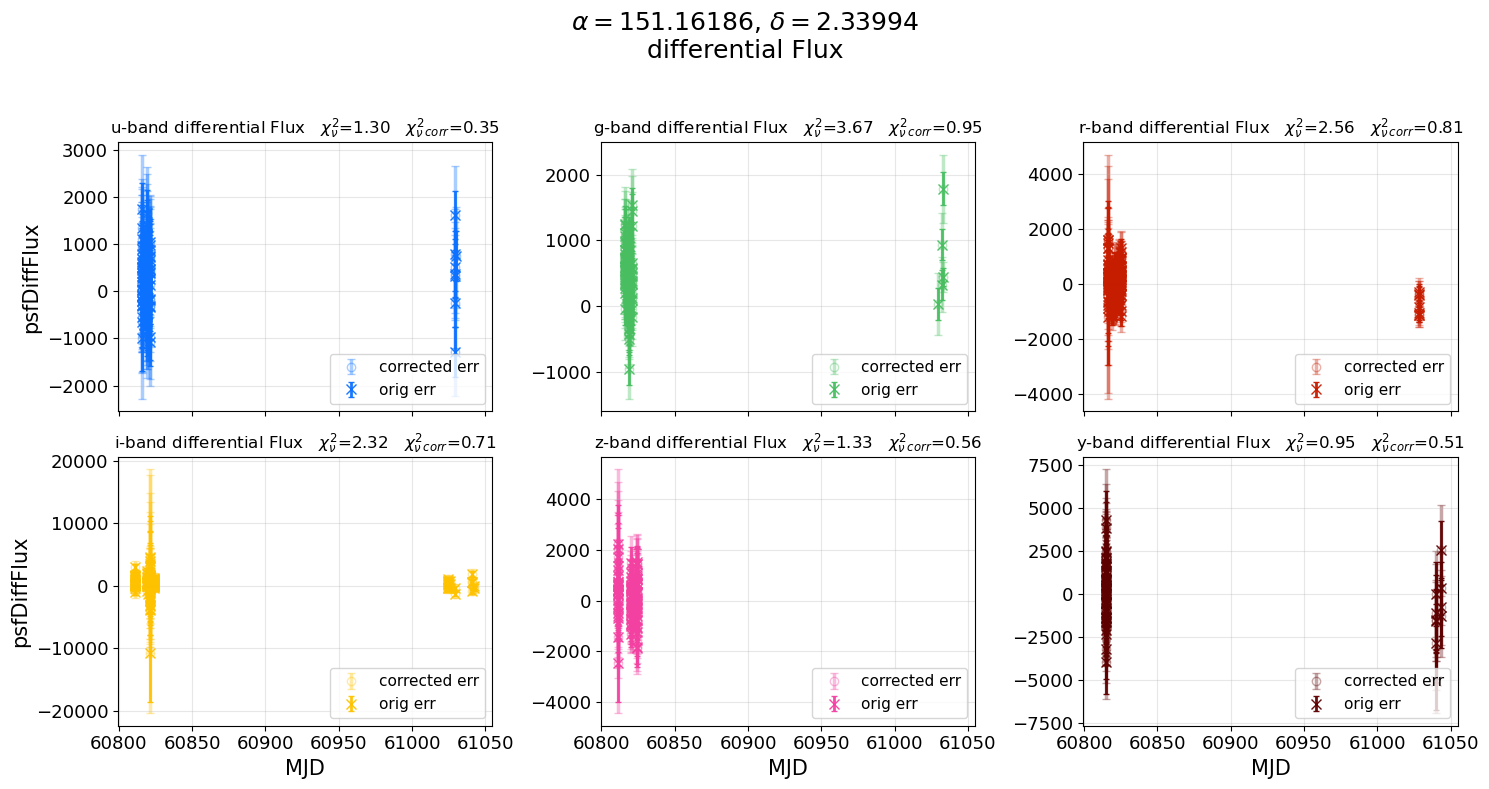

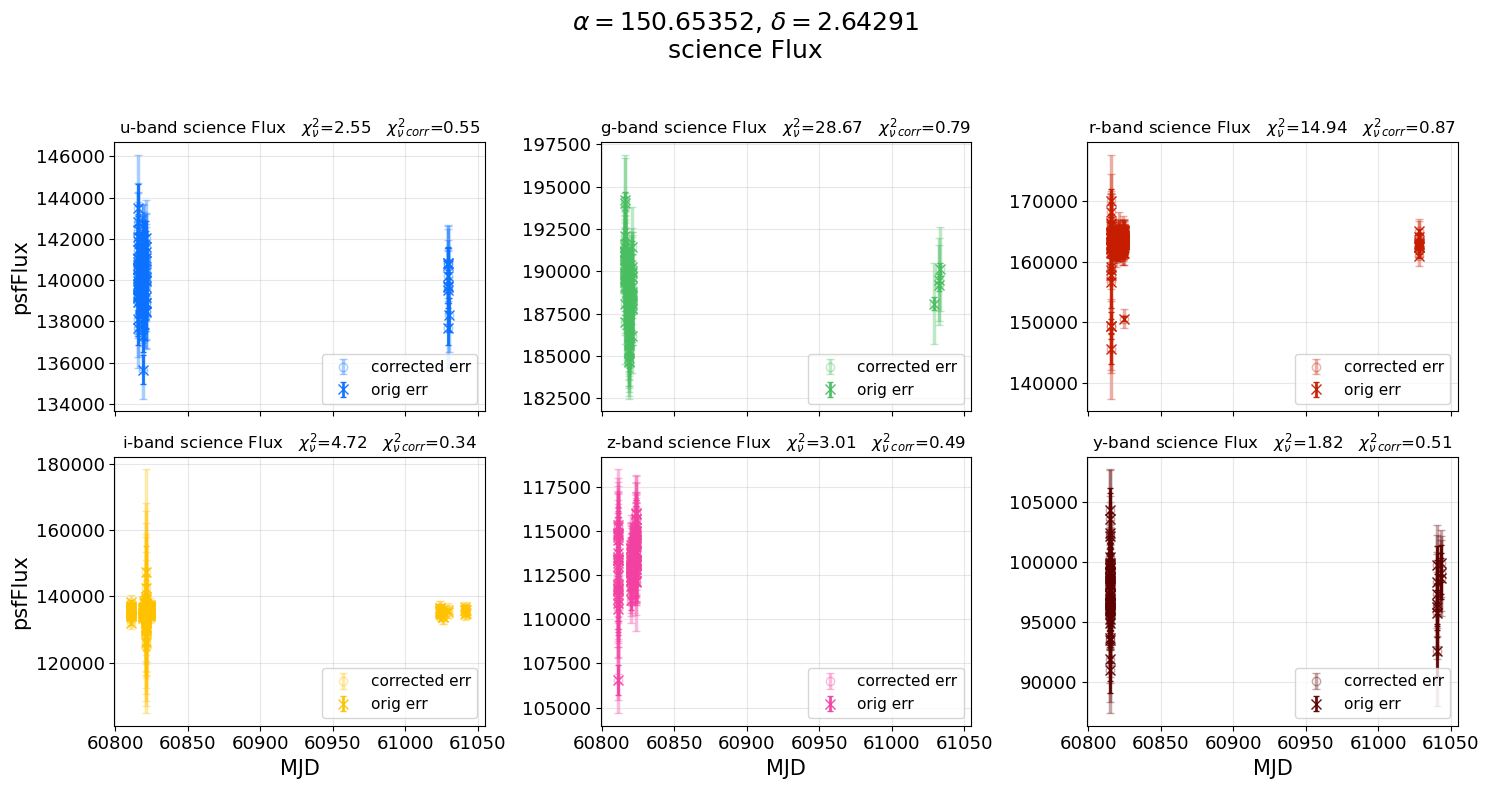

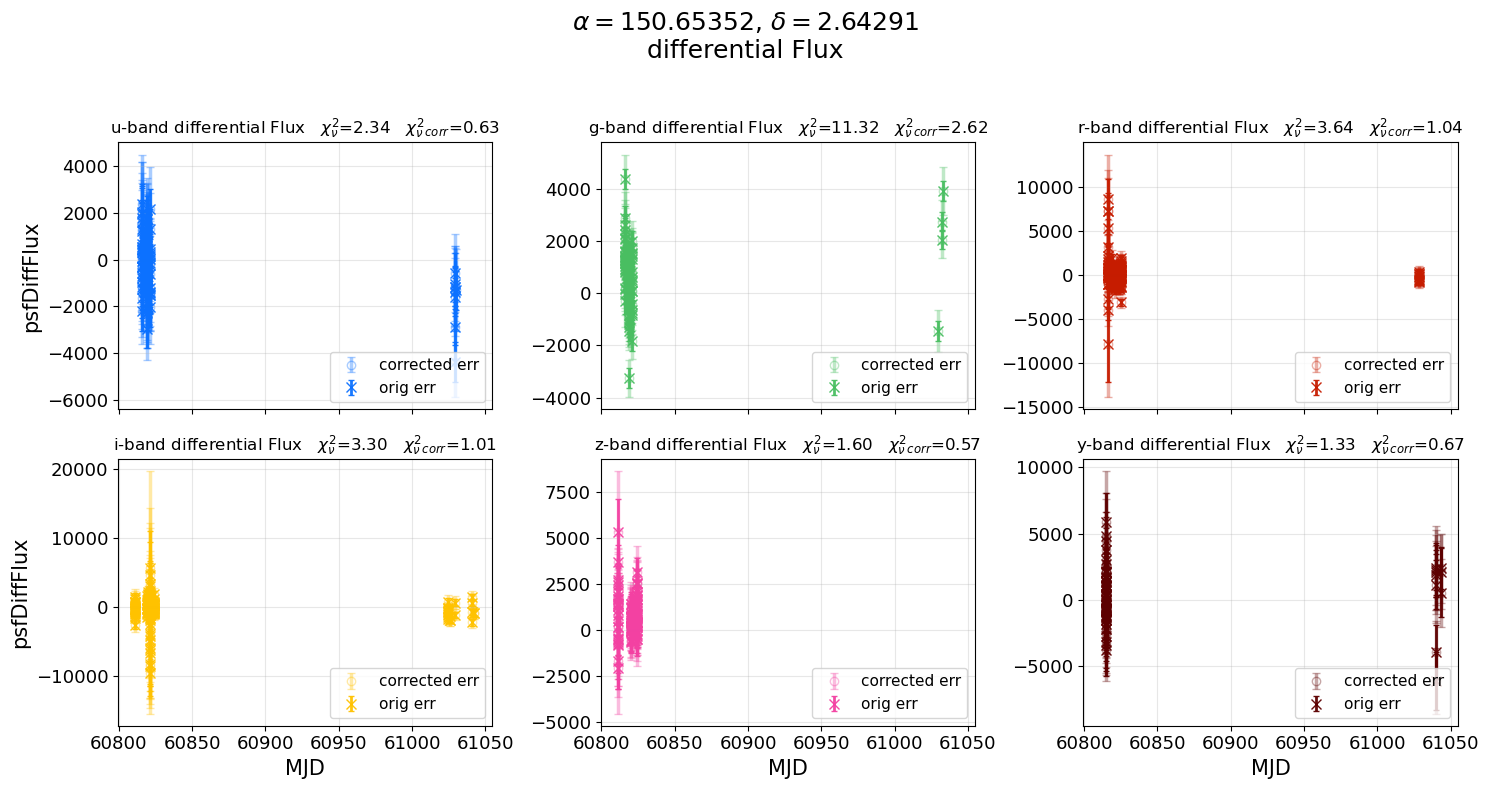

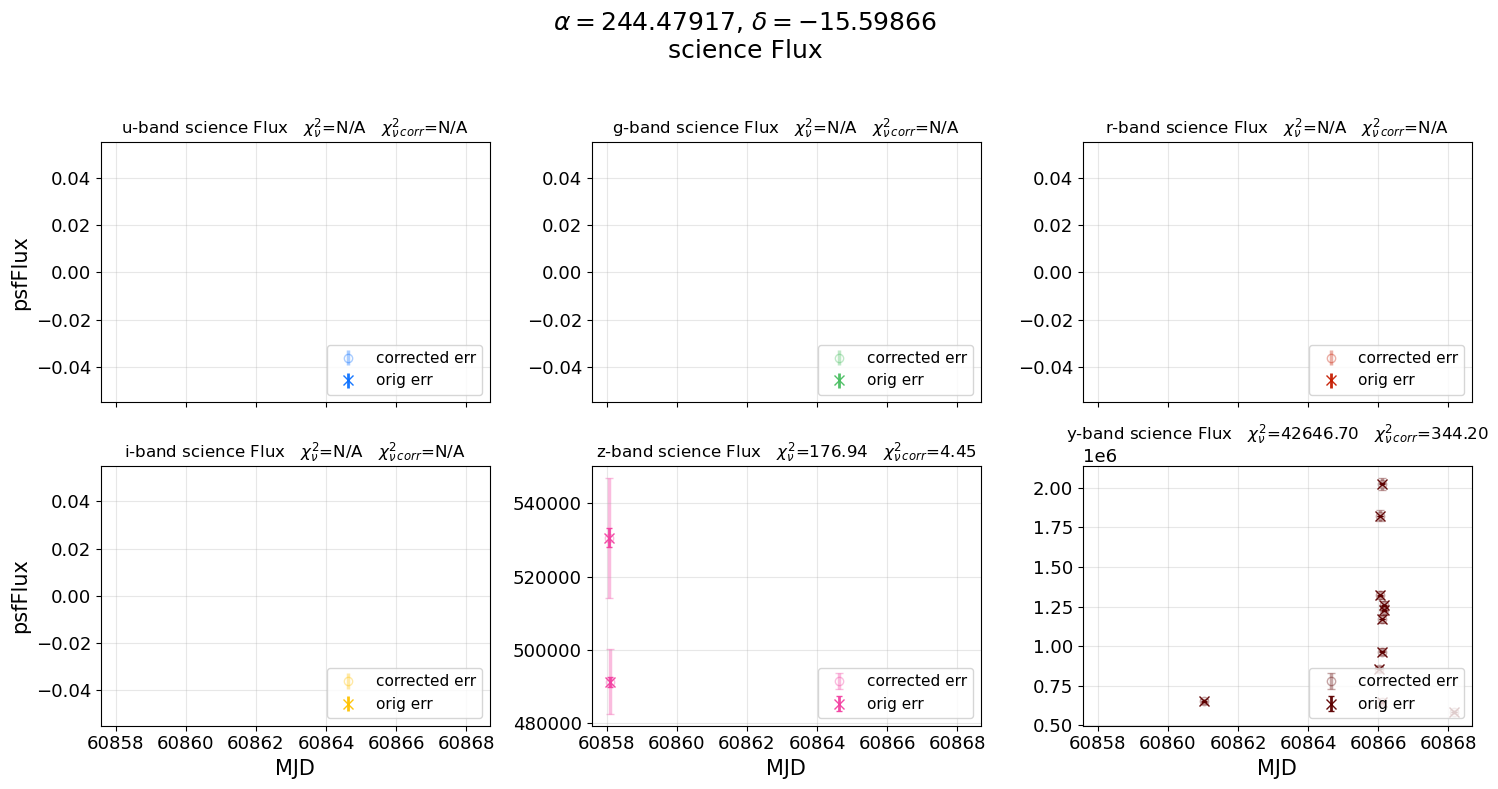

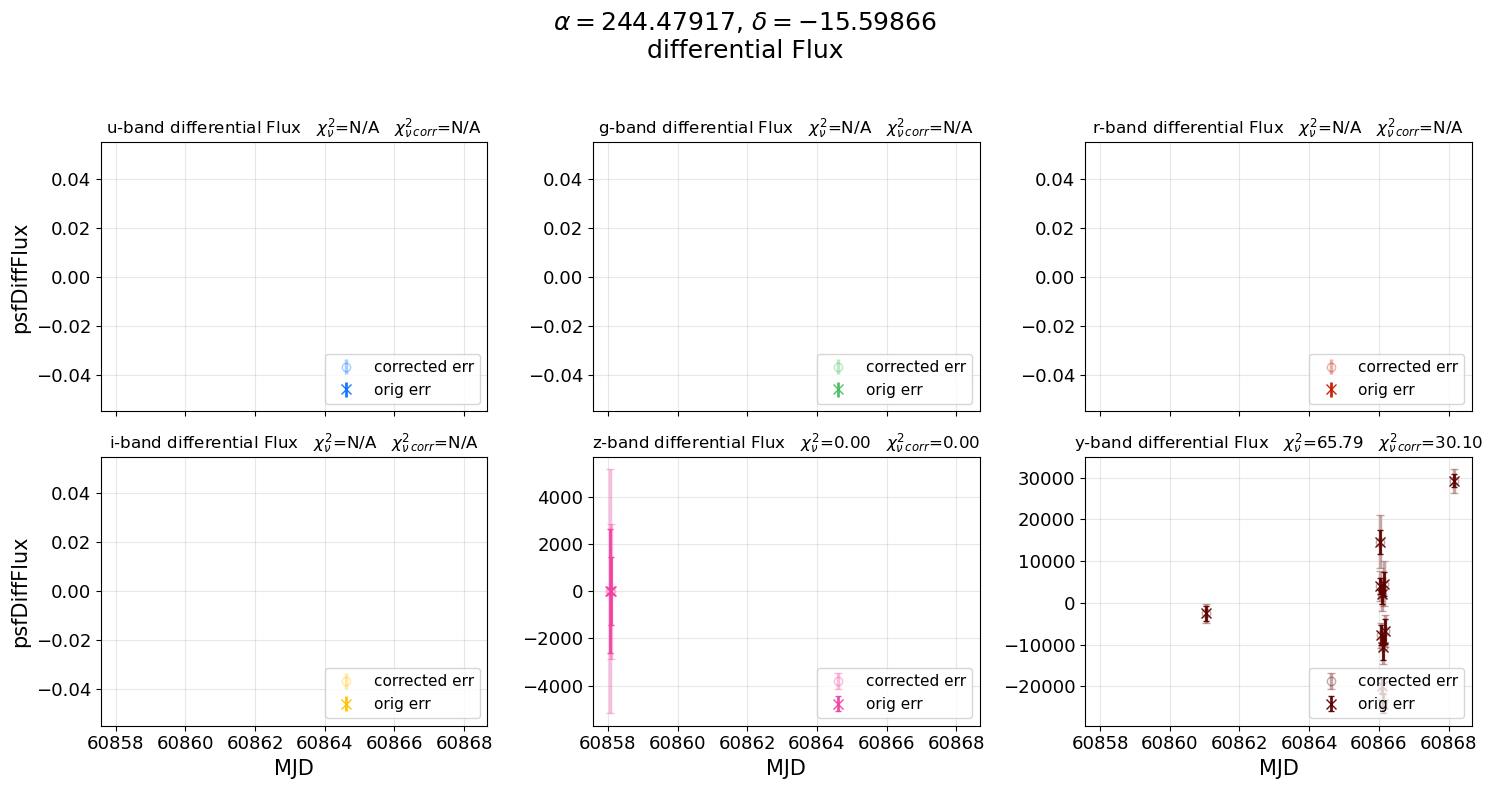

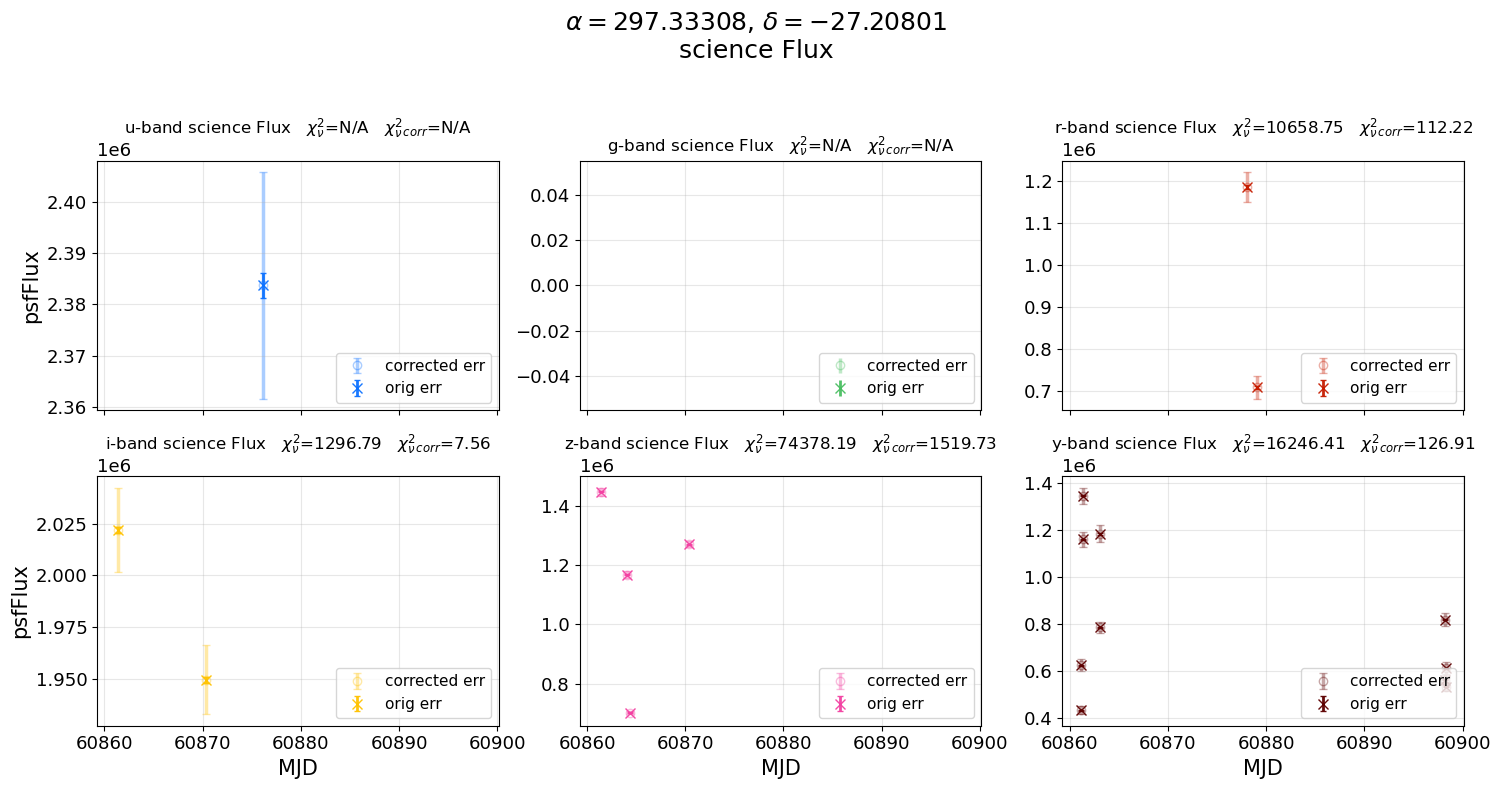

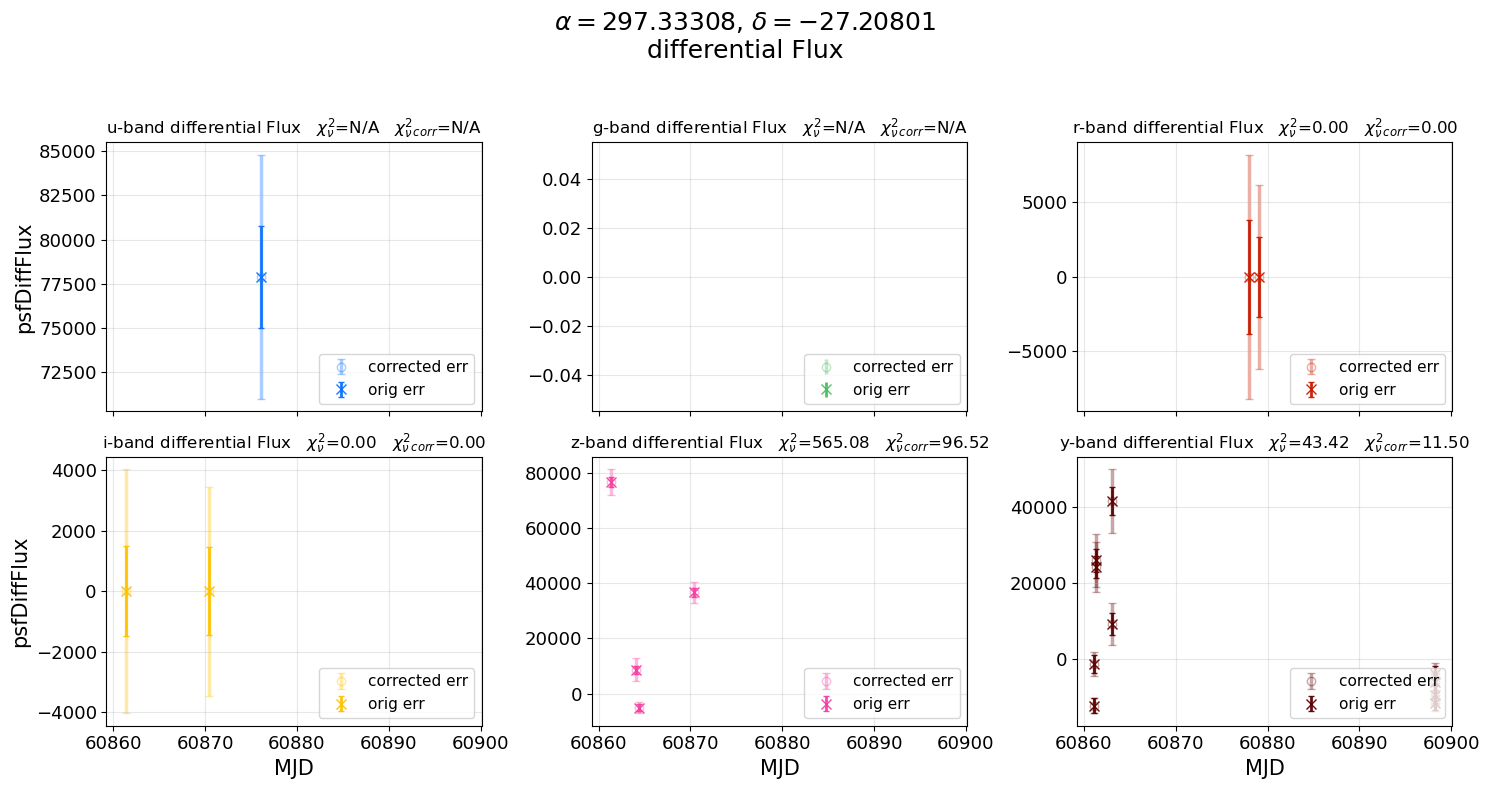

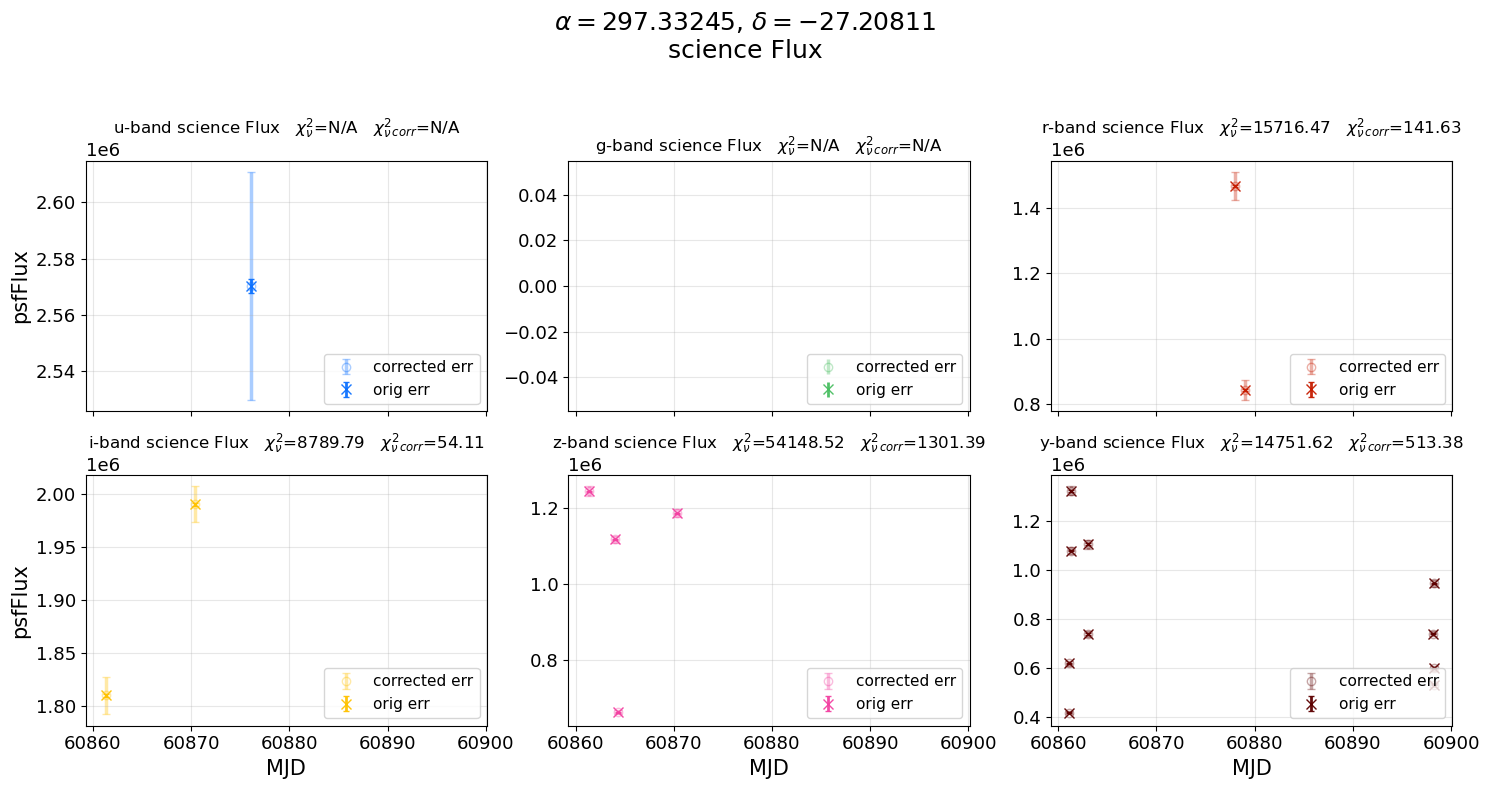

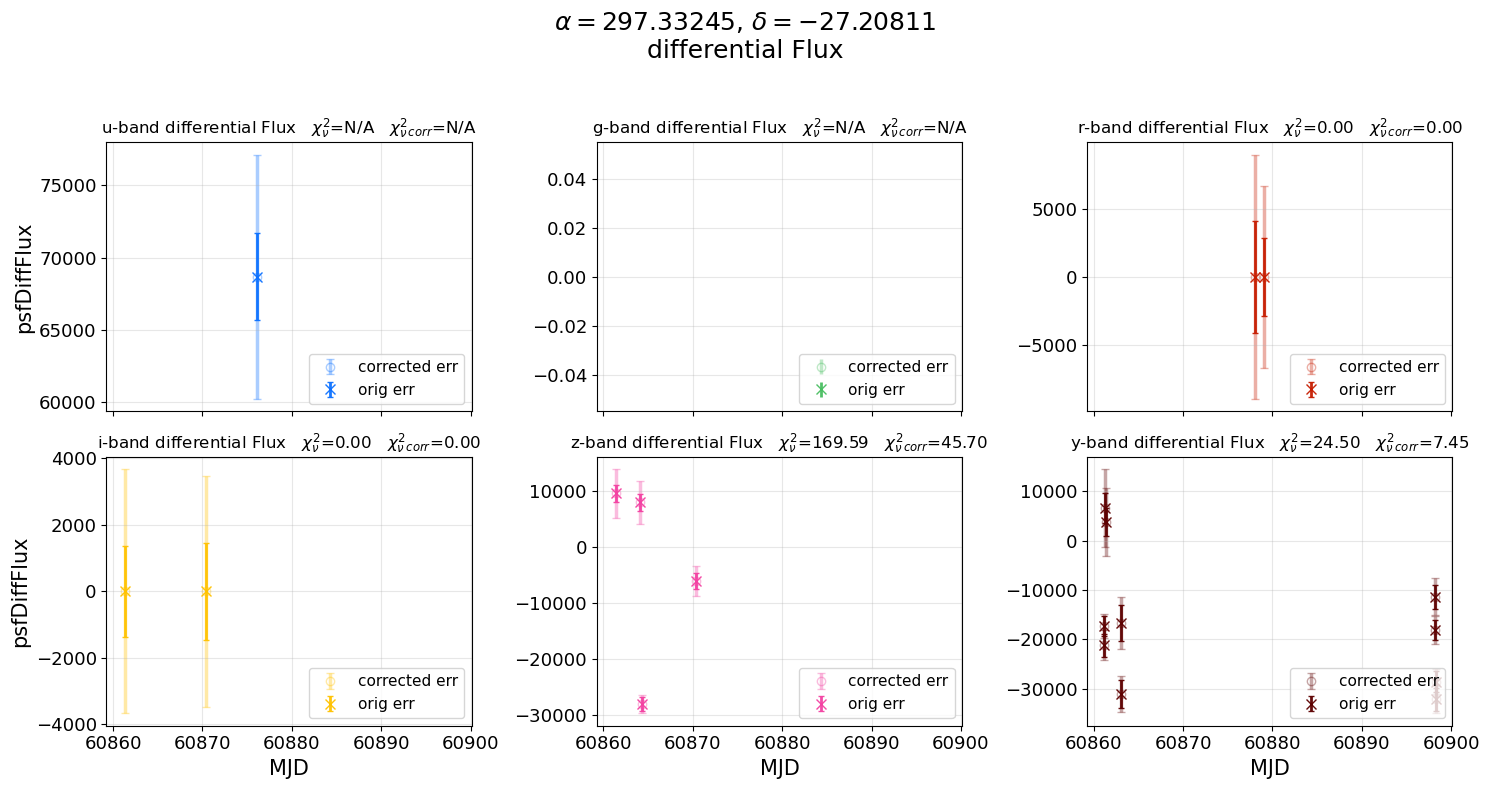

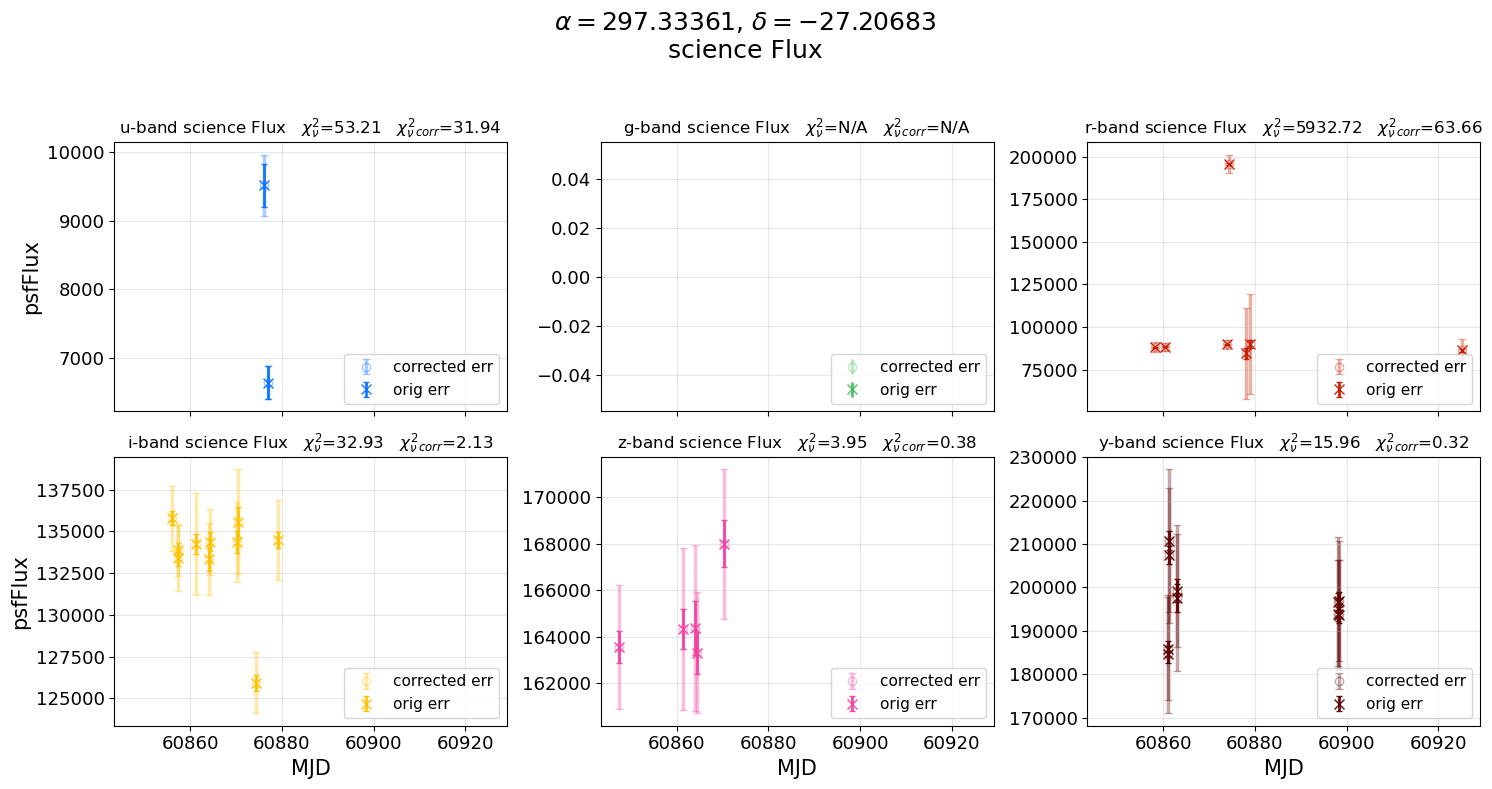

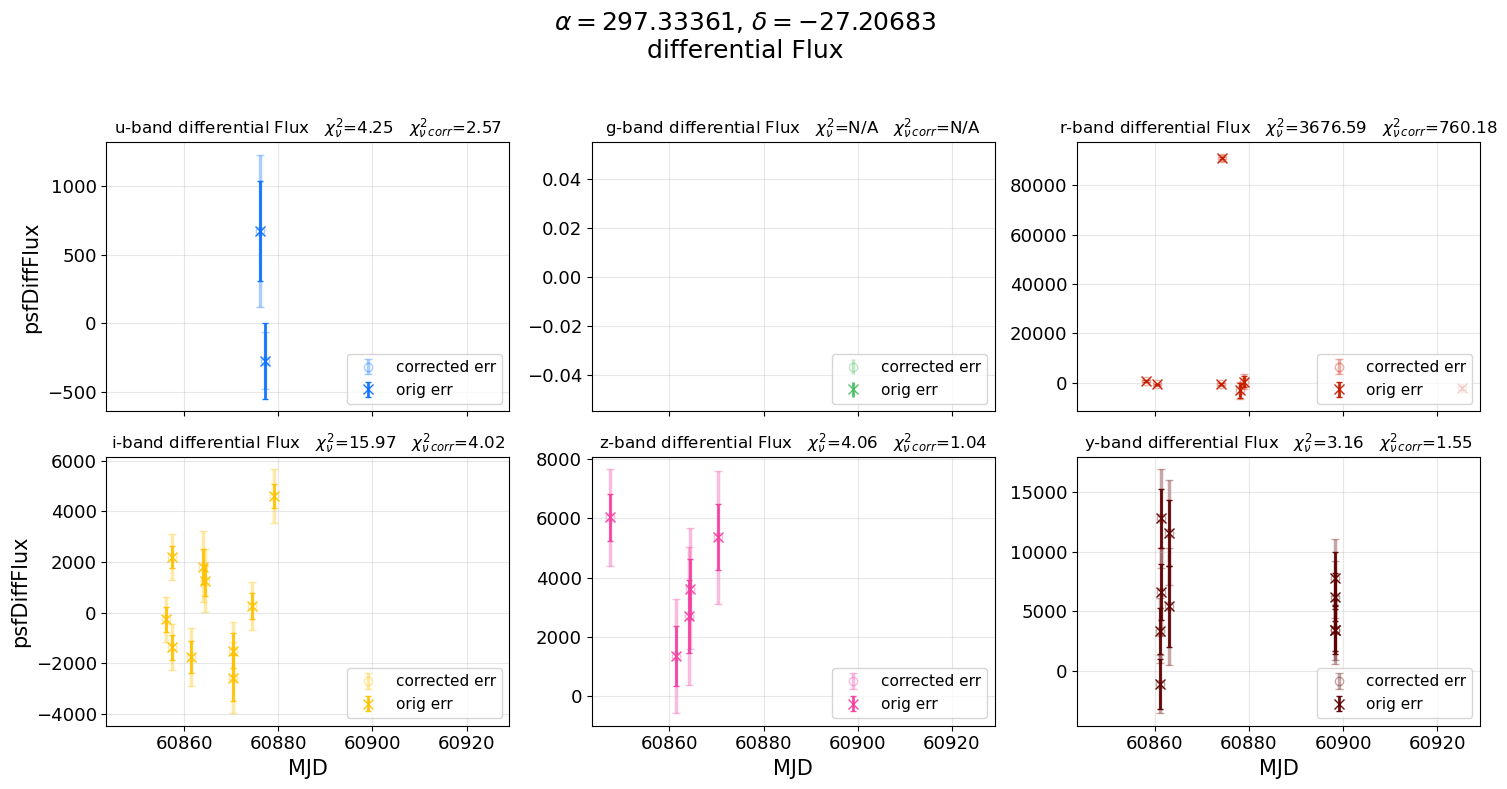

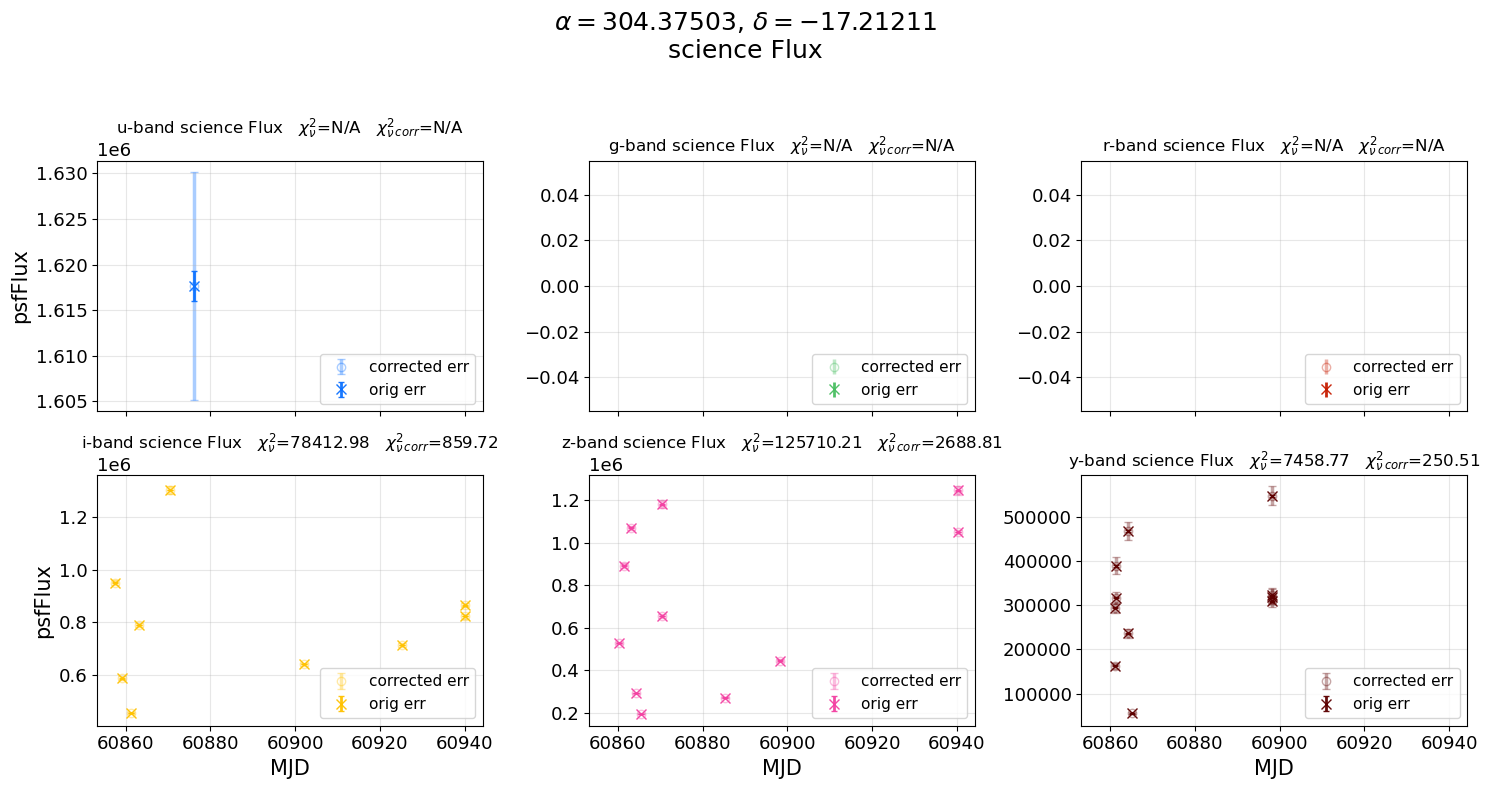

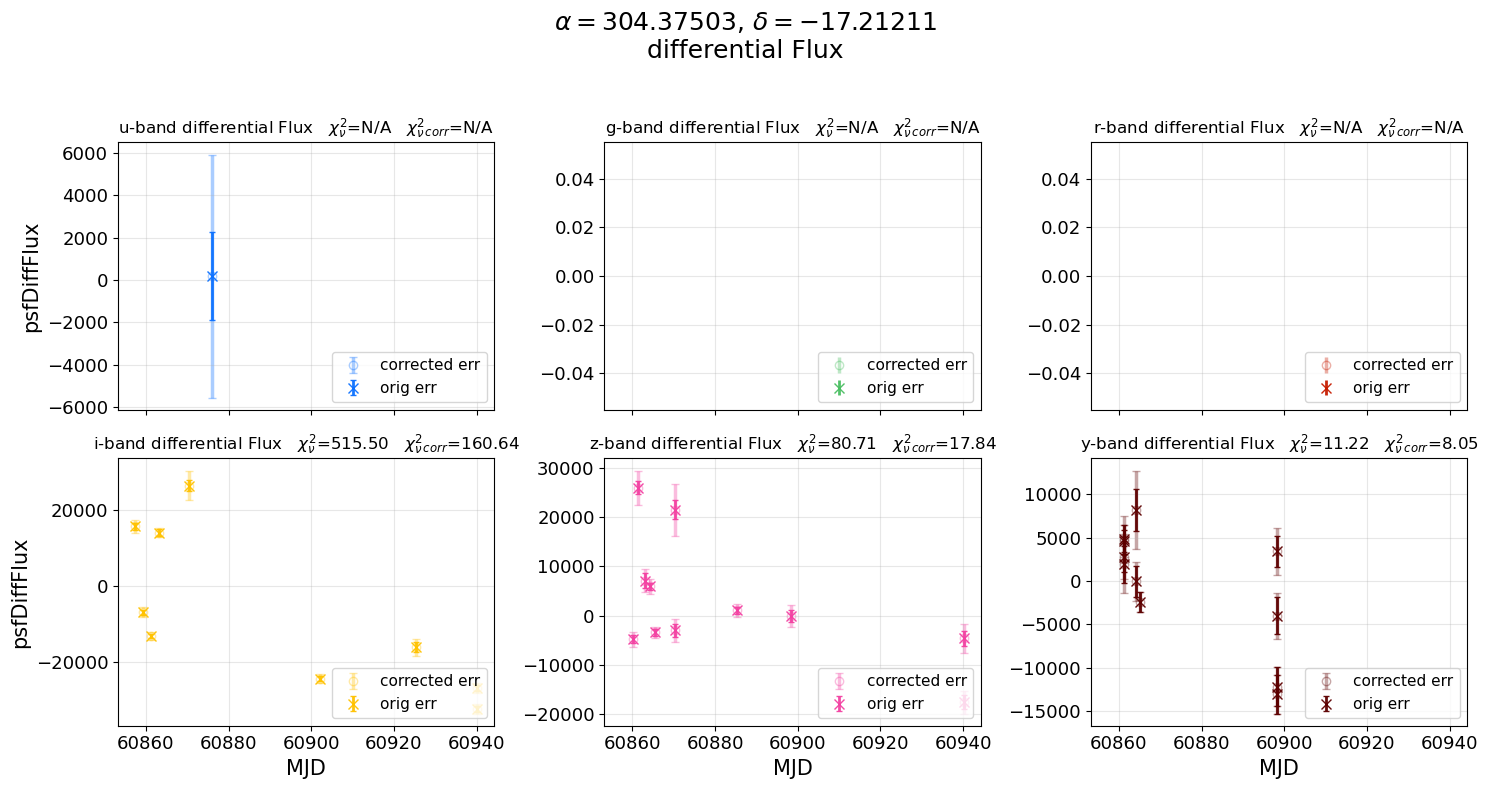

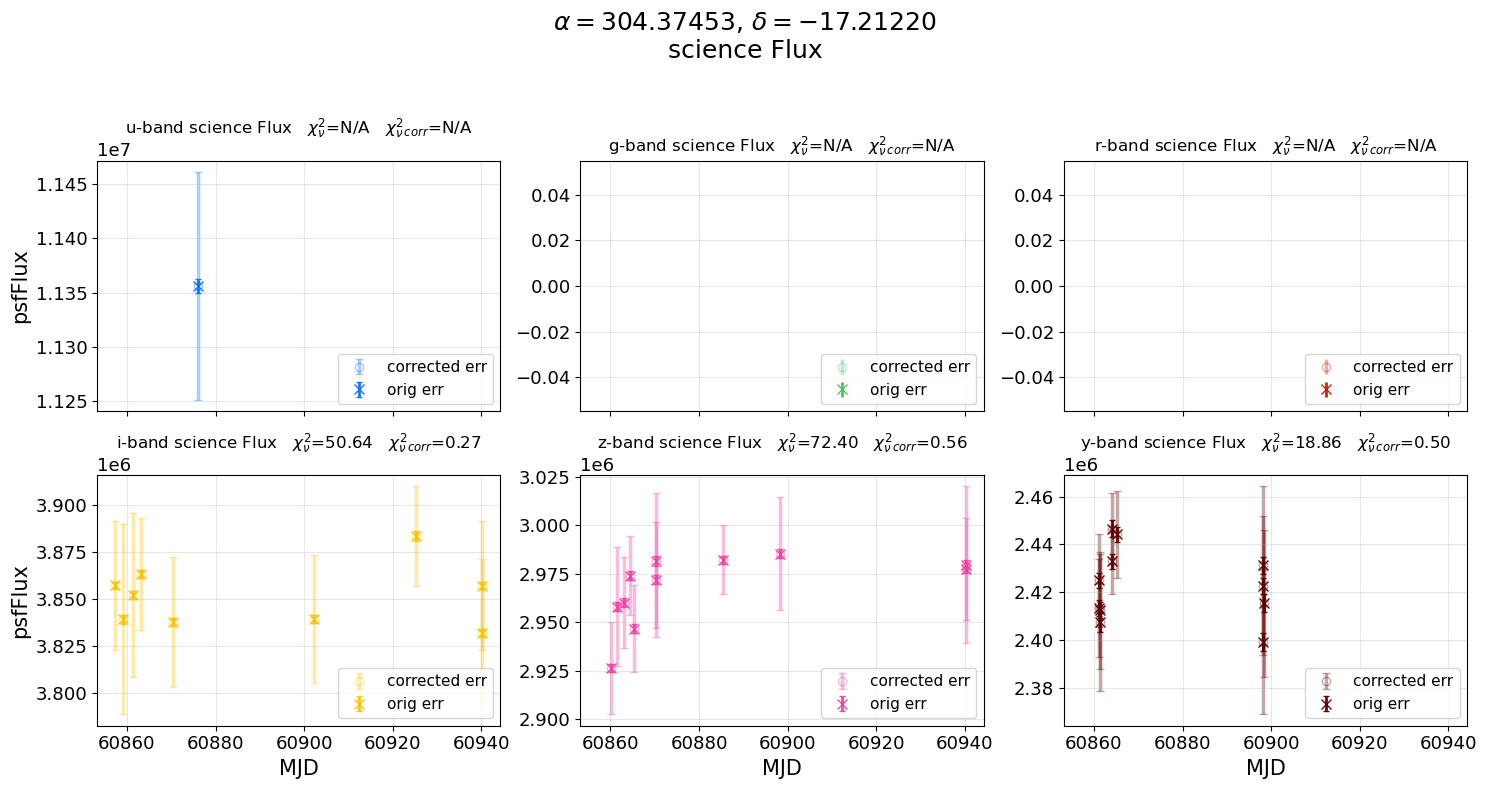

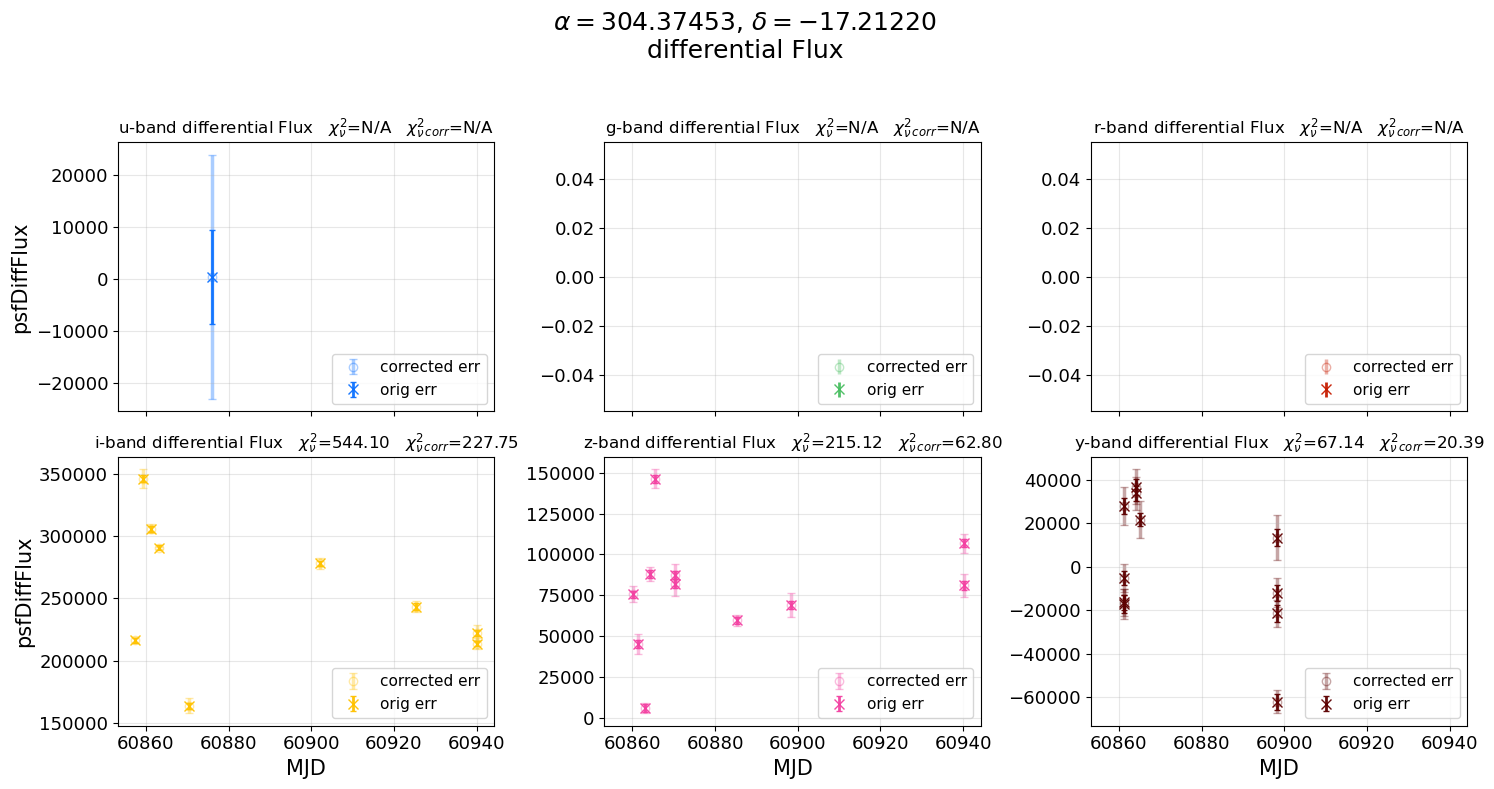

In [ ]:
LSST_BAND_COLORS = {
    "u": "#0c71ff",
    "g": "#49be61",
    "r": "#c61c00",
    "i": "#ffc200",
    "z": "#f341a2",
    "y": "#5d0000",
}

bands = "ugrizy"


def reduced_chi2(y, yerr):
    n = len(y)
    if n <= 1:
        return None

    wmean = np.average(y, weights=1 / yerr**2)
    chi2 = np.sum(((y - wmean) / yerr) ** 2)
    return chi2 / (n - 1)


def chi2_text(value):
    return "N/A" if value is None else f"{value:.2f}"


def plot_for_flux(
    forced_sources,
    ra,
    dec,
    plot_title,
    flux_col,
    err_col,
    err_corr_col,
    flag_col,
    invalid_flag_col=None,
):
    fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
    axes = axes.ravel()

    fig.suptitle(rf"$\alpha={ra:.5f}$, $\delta={dec:.5f}$" f"\n{plot_title}")

    for ax, band in zip(axes, bands):
        color = LSST_BAND_COLORS[band]

        mask = (
            (forced_sources["band"] == band)
            & (~forced_sources[flag_col])
            & (~forced_sources["pixelFlags_bad"])
            & (~forced_sources["pixelFlags_saturated"])
            & (~forced_sources["pixelFlags_nodata"])
        )
        if invalid_flag_col is not None and invalid_flag_col in forced_sources.columns:
            mask &= ~forced_sources[invalid_flag_col]

        lc = forced_sources[mask].copy()

        chi2_orig = reduced_chi2(lc[flux_col], lc[err_col])
        chi2_corr = reduced_chi2(lc[flux_col], lc[err_corr_col])

        ax.errorbar(
            lc["midpointMjdTai"],
            lc[flux_col],
            yerr=lc[err_corr_col],
            color=color,
            linestyle="none",
            marker="o",
            markersize=6,
            markerfacecolor="none",
            markeredgewidth=1.0,
            alpha=0.35,
            elinewidth=2.5,
            capsize=3,
            zorder=1,
            label="corrected err",
        )

        ax.errorbar(
            lc["midpointMjdTai"],
            lc[flux_col],
            yerr=lc[err_col],
            color=color,
            linestyle="none",
            marker="x",
            markersize=7,
            alpha=0.95,
            elinewidth=2.0,
            capsize=2,
            zorder=2,
            label="orig err",
        )

        ax.set_title(
            f"{band}-band {plot_title}   "
            f"$\\chi^2_\\nu$={chi2_text(chi2_orig)}   "
            f"$\\chi^2_\\nu$$_{{corr}}$={chi2_text(chi2_corr)}",
            fontsize=12,
        )
        ax.grid(alpha=0.3)
        ax.legend(loc="lower right", fontsize=11)

    axes[0].set_ylabel(flux_col)
    axes[3].set_ylabel(flux_col)
    for ax in axes[3:]:
        ax.set_xlabel("MJD")

    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


for row_index in range(len(df)):
    row = df.iloc[row_index]
    forced_sources = row["objectForcedSource"]
    ra = row["coord_ra"]
    dec = row["coord_dec"]

    plot_configs = [
        (
            "science Flux",
            "psfFlux",
            "psfFluxErr",
            "psfFluxErr_corrected",
            "psfFlux_flag",
            "invalidPsfFlag",
        ),
        (
            "differential Flux",
            "psfDiffFlux",
            "psfDiffFluxErr",
            "psfDiffFluxErr_corrected",
            "psfDiffFlux_flag",
            None,
        ),
    ]

    for plot_title, flux_col, err_col, err_corr_col, flag_col, invalid_flag_col in plot_configs:
        plot_for_flux(
            forced_sources=forced_sources,
            ra=ra,
            dec=dec,
            plot_title=plot_title,
            flux_col=flux_col,
            err_col=err_col,
            err_corr_col=err_corr_col,
            flag_col=flag_col,
            invalid_flag_col=invalid_flag_col,
        )

Bright objects see their errors slightly overestimated, by about 30%, in exchange for reliably catching large error underestimation present in the original data.

## About

**Authors**: Konstantin Malanchev

**Last updated on**: Jul 21, 2026

If you use `lsdb` for published research, please cite following [instructions](https://docs.lsdb.io/en/stable/citation.html).